In [2]:
#Objective:
#Estimate the medical insurance claim amount based on personal data.
#Dataset:
#Medical Cost Personal Dataset


In [4]:
# Import necessary libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [8]:
# Set style for better visualizations

In [10]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [12]:
# Load the dataset
df = pd.read_csv("OneDrive/Comsats/Internship/datasets/insurance.csv")

In [16]:
# Display first few rows and basic info
print("Dataset Overview:")
print("="*50)
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDataset Statistics:")
print(df.describe())

Dataset Overview:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Dataset Statistics:
               age          bmi     c

In [18]:
print("Dataset Overview:")
print("="*50)
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDataset Statistics:")
print(df.describe())

Dataset Overview:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Dataset Statistics:
               age          bmi     c

In [20]:
# Check for missing values

In [22]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [24]:
# Data Preprocessing
# Encode categorical variables

In [26]:
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'])
df['smoker'] = le_smoker.fit_transform(df['smoker'])
df['region'] = le_region.fit_transform(df['region'])


In [28]:
# Define features and target

In [30]:
X = df.drop('charges', axis=1)
y = df['charges']

In [32]:
# Split the data into training and testing sets

In [34]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Scale the features for better model performance


In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [40]:
# Train Linear Regression model

In [44]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [46]:
# Make predictions

In [48]:

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)


In [50]:
# Model Evaluation

In [52]:
print("\n" + "="*50)
print("Model Performance Metrics:")
print("="*50)


Model Performance Metrics:


In [54]:
# Calculate metrics for training set

In [56]:

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

In [58]:
# Calculate metrics for testing set

In [60]:

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

In [62]:
print(f"Training Set - MAE: ${mae_train:,.2f}")
print(f"Training Set - RMSE: ${rmse_train:,.2f}")
print(f"Testing Set - MAE: ${mae_test:,.2f}")
print(f"Testing Set - RMSE: ${rmse_test:,.2f}")


Training Set - MAE: $4,208.76
Training Set - RMSE: $6,105.79
Testing Set - MAE: $4,186.51
Testing Set - RMSE: $5,799.59


In [64]:
# Display model coefficients

In [66]:
print("\n" + "="*50)
print("Model Coefficients:")
print("="*50)
feature_names = X.columns
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
})
coefficients['Absolute_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Absolute_Coefficient', ascending=False)
print(coefficients)


Model Coefficients:
    Feature  Coefficient  Absolute_Coefficient
4    smoker  9557.143383           9557.143383
0       age  3616.108652           3616.108652
2       bmi  2028.308579           2028.308579
3  children   516.662566            516.662566
5    region  -302.387980            302.387980
1       sex    -9.392954              9.392954


In [68]:
# Visualizations

In [72]:
print("\n" + "="*50)
print("Generating Visualizations...")
print("="*50)


Generating Visualizations...


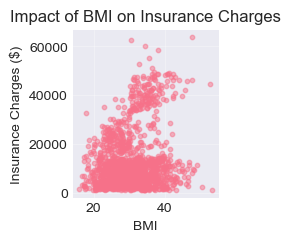

In [74]:
# 1. Impact of BMI on Insurance Charges
plt.subplot(2, 3, 1)
plt.scatter(df['bmi'], df['charges'], alpha=0.5, s=10)
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.title('Impact of BMI on Insurance Charges')
plt.grid(True, alpha=0.3)

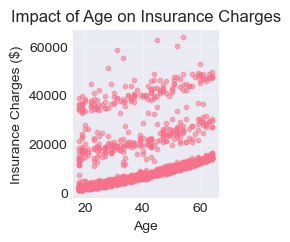

In [76]:
# 2. Impact of Age on Insurance Charges
plt.subplot(2, 3, 2)
plt.scatter(df['age'], df['charges'], alpha=0.5, s=10)
plt.xlabel('Age')
plt.ylabel('Insurance Charges ($)')
plt.title('Impact of Age on Insurance Charges')
plt.grid(True, alpha=0.3)

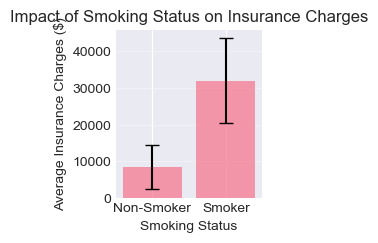

In [78]:
# 3. Impact of Smoking Status on Insurance Charges
plt.subplot(2, 3, 3)
smoker_charges = df.groupby('smoker')['charges'].agg(['mean', 'std'])
categories = ['Non-Smoker', 'Smoker']
plt.bar(categories, smoker_charges['mean'], 
        yerr=smoker_charges['std'], capsize=5, alpha=0.7)
plt.xlabel('Smoking Status')
plt.ylabel('Average Insurance Charges ($)')
plt.title('Impact of Smoking Status on Insurance Charges')
plt.grid(True, alpha=0.3, axis='y')


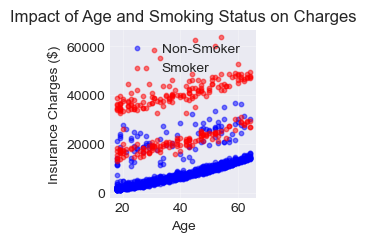

In [80]:
# 4. Combined Impact: Age and Smoking Status
plt.subplot(2, 3, 4)
for smoker_status, color in zip([0, 1], ['blue', 'red']):
    subset = df[df['smoker'] == smoker_status]
    plt.scatter(subset['age'], subset['charges'], 
               alpha=0.5, s=10, color=color, 
               label='Smoker' if smoker_status == 1 else 'Non-Smoker')
plt.xlabel('Age')
plt.ylabel('Insurance Charges ($)')
plt.title('Impact of Age and Smoking Status on Charges')
plt.legend()
plt.grid(True, alpha=0.3)

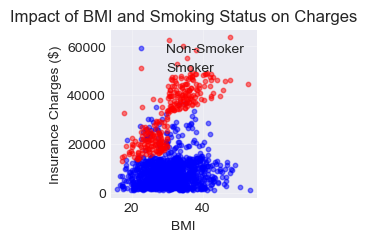

In [82]:
# 5. Combined Impact: BMI and Smoking Status
plt.subplot(2, 3, 5)
for smoker_status, color in zip([0, 1], ['blue', 'red']):
    subset = df[df['smoker'] == smoker_status]
    plt.scatter(subset['bmi'], subset['charges'], 
               alpha=0.5, s=10, color=color, 
               label='Smoker' if smoker_status == 1 else 'Non-Smoker')
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.title('Impact of BMI and Smoking Status on Charges')
plt.legend()
plt.grid(True, alpha=0.3)

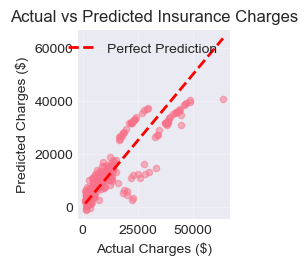

In [84]:
# 6. Actual vs Predicted Values
plt.subplot(2, 3, 6)
plt.scatter(y_test, y_pred_test, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

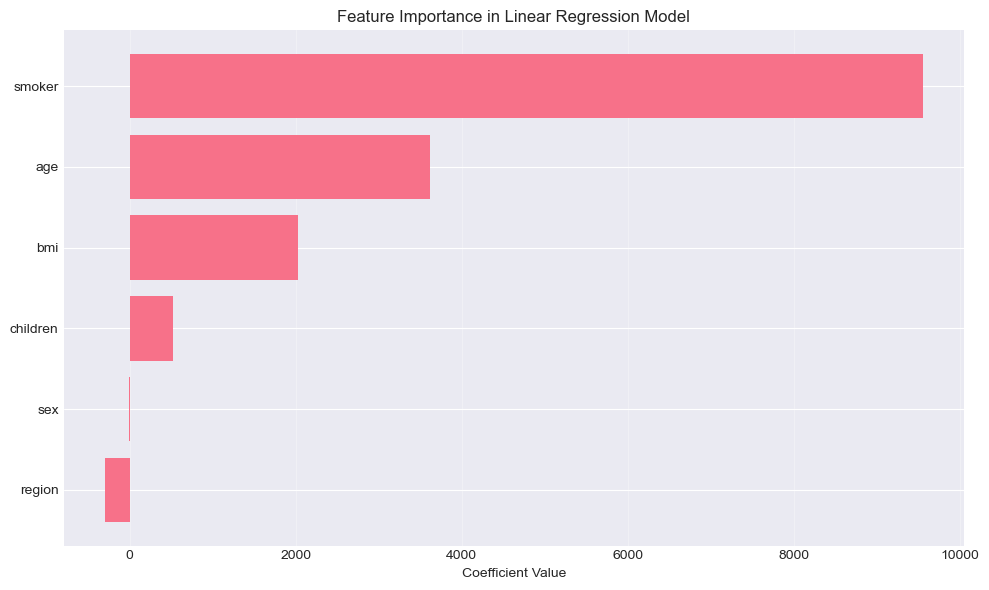

In [86]:

# Additional Visualization: Feature Importance
plt.figure(figsize=(10, 6))
coefficients_sorted = coefficients.sort_values('Coefficient', ascending=True)
plt.barh(coefficients_sorted['Feature'], coefficients_sorted['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression Model')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()